# 📊 Student Performance Analysis

**Author:** Reha Arif
**Project type:** Data Analysis (Exploratory Data Analysis + Insights)

This notebook analyzes a student performance dataset covering marks, attendance,
and study habits across subjects and classes. The goal is to identify the factors
most strongly associated with academic performance and to produce actionable
recommendations.

**Dataset columns:**
| Column | Description |
|---|---|
| `student_id` | Unique identifier per student |
| `name` | Student name |
| `gender` | Male / Female |
| `class` | Grade + section, e.g. `10-A` |
| `subject` | Subject the marks/row refers to |
| `marks` | Marks scored (0–100) |
| `attendance_percentage` | Overall attendance % |
| `study_hours` | Average daily self-study hours |

---


## 1. Import Libraries

We import the core data-analysis and visualization stack: `pandas` and `numpy` for data handling, `matplotlib` and `seaborn` for visualization.

In [1]:
# Core data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook / display settings
%matplotlib inline
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries imported successfully.")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Libraries imported successfully.
Pandas version: 3.0.2
NumPy version: 2.4.4


## 2. Load Dataset

We load `student_performance.csv` (a student-subject level dataset: one row per
student per subject).

In [2]:
# Load the dataset
df = pd.read_csv("student_performance.csv")

# Preview the first few rows
df.head(10)

,student_id,name,gender,class,subject,marks,attendance_percentage,study_hours
0,1099,Hassan Baig,Female,12-B,Computer Science,64.4,79.3,3.6
1,1119,Kamran Yousaf,Female,12-A,English,45.0,70.7,4.0
2,1199,Kinza Sheikh,Male,11-B,Mathematics,69.1,81.4,2.7
3,1183,Danish Rana,Male,11-A,History,53.3,71.0,0.0
4,1138,Kamran Sheikh,Male,9-B,Mathematics,100.0,96.6,6.6
5,1021,Noman Shah,Male,11-B,Science,56.9,79.8,2.1
6,1089,Ahmed Khan,Male,12-B,History,48.6,65.9,0.0
7,1156,Kinza Sheikh,Female,9-A,Science,68.6,67.0,3.5
8,1090,Bushra Butt,Male,12-B,Science,49.6,72.3,1.9
9,1093,Farah Hussain,Female,10-B,Computer Science,93.0,92.0,5.9


In [3]:
# Shape of the dataset (rows, columns)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")

Dataset shape: 1515 rows, 8 columns


In [4]:
# Structure, dtypes, and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1515 entries, 0 to 1514
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   student_id             1515 non-null   int64  
 1   name                   1515 non-null   str    
 2   gender                 1515 non-null   str    
 3   class                  1515 non-null   str    
 4   subject                1515 non-null   str    
 5   marks                  1484 non-null   float64
 6   attendance_percentage  1484 non-null   float64
 7   study_hours            1485 non-null   float64
dtypes: float64(3), int64(1), str(4)
memory usage: 94.8 KB


In [5]:
# Quick statistical summary of numeric columns
df.describe()

,student_id,marks,attendance_percentage,study_hours
count,1515.000000,1484.000000,1484.000000,1485.000000
mean,1150.201980,64.674596,73.992520,2.793805
std,86.713517,44.989515,11.247685,1.607077
min,1001.000000,-5.000000,-10.000000,0.000000
25%,1075.000000,51.700000,66.800000,1.700000
50%,1150.000000,63.650000,74.300000,2.900000
75%,1225.000000,73.500000,81.700000,3.900000
max,1300.000000,999.000000,150.000000,6.800000


## 3. Data Cleaning

Real-world student data typically has: missing values,
duplicate rows, invalid/out-of-range values, inconsistent text formatting, and
wrong data types. We handle each issue  below.

### 3.1 Check for missing values

In [6]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_summary[missing_summary['missing_count'] > 0]

,missing_count,missing_pct
marks,31,2.05
attendance_percentage,31,2.05
study_hours,30,1.98


### 3.2 Check and remove duplicate rows

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {duplicate_count}")

# Drop duplicates, keep the first occurrence
df = df.drop_duplicates().reset_index(drop=True)
print(f"Shape after removing duplicates: {df.shape}")

Number of exact duplicate rows: 15
Shape after removing duplicates: (1500, 8)


### 3.3 Fix data types

`study_hours` was stored as text in a few rows (mixed dtype). We coerce it to numeric.

In [8]:
# Force study_hours to numeric; invalid parses become NaN (to be handled next)
df['study_hours'] = pd.to_numeric(df['study_hours'], errors='coerce')

# Confirm dtypes are now consistent
df.dtypes

student_id                 int64
name                         str
gender                       str
class                        str
subject                      str
marks                    float64
attendance_percentage    float64
study_hours              float64
dtype: object

### 3.4 Clean invalid / out-of-range values

Marks should be within 0–100 and attendance within 0–100%. Values outside this range are data-entry errors and are treated as missing, then imputed.

In [9]:
# Flag out-of-range values as NaN
df.loc[(df['marks'] < 0) | (df['marks'] > 100), 'marks'] = np.nan
df.loc[(df['attendance_percentage'] < 0) | (df['attendance_percentage'] > 100), 'attendance_percentage'] = np.nan

print("Out-of-range values converted to NaN.")
print(df[['marks', 'attendance_percentage', 'study_hours']].isnull().sum())

Out-of-range values converted to NaN.
marks                    36
attendance_percentage    34
study_hours              30
dtype: int64


### 3.5 Standardize text columns

Trim whitespace and normalize casing in categorical columns like `gender`.

In [10]:
df['gender'] = df['gender'].astype(str).str.strip().str.title()
df['class'] = df['class'].astype(str).str.strip()
df['subject'] = df['subject'].astype(str).str.strip()

print("Unique gender values after cleaning:", df['gender'].unique())
print("Unique class values after cleaning:", sorted(df['class'].unique()))

Unique gender values after cleaning: <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Unique class values after cleaning: ['10-A', '10-B', '11-A', '11-B', '12-A', '12-B', '9-A', '9-B']


### 3.6 Handle missing numeric values

We impute missing `marks`, `attendance_percentage`, and `study_hours` using the **median** of their respective subject/overall group, which is robust to outliers.

In [11]:
# Impute marks using the subject-wise median (different subjects have different difficulty)
df['marks'] = df.groupby('subject')['marks'].transform(lambda x: x.fillna(x.median()))

# Impute attendance and study_hours using the overall median
df['attendance_percentage'] = df['attendance_percentage'].fillna(df['attendance_percentage'].median())
df['study_hours'] = df['study_hours'].fillna(df['study_hours'].median())

# Final check: no missing values should remain
print("Remaining missing values:\n", df.isnull().sum())

Remaining missing values:
 student_id               0
name                     0
gender                   0
class                    0
subject                  0
marks                    0
attendance_percentage    0
study_hours              0
dtype: int64


In [12]:
# Round numeric columns for cleanliness
df['marks'] = df['marks'].round(1)
df['attendance_percentage'] = df['attendance_percentage'].round(1)
df['study_hours'] = df['study_hours'].round(1)

print(f"Final cleaned dataset shape: {df.shape}")
df.head()

Final cleaned dataset shape: (1500, 8)


,student_id,name,gender,class,subject,marks,attendance_percentage,study_hours
0,1099,Hassan Baig,Female,12-B,Computer Science,64.4,79.3,3.6
1,1119,Kamran Yousaf,Female,12-A,English,45.0,70.7,4.0
2,1199,Kinza Sheikh,Male,11-B,Mathematics,69.1,81.4,2.7
3,1183,Danish Rana,Male,11-A,History,53.3,71.0,0.0
4,1138,Kamran Sheikh,Male,9-B,Mathematics,100.0,96.6,6.6


## 4. Exploratory Data Analysis (EDA)

### 4.1 Subject-wise and overall performance trends

In [13]:
subject_performance = df.groupby('subject')['marks'].agg(['mean', 'median', 'std', 'min', 'max']).round(2)
subject_performance = subject_performance.sort_values('mean', ascending=False)
subject_performance

,mean,median,std,min,max
subject,,,,,
English,66.12,67.1,15.49,15.7,100.0
History,64.77,64.7,15.34,23.9,100.0
Computer Science,64.16,64.4,15.31,21.0,99.7
Science,61.35,61.5,14.89,10.9,100.0
Mathematics,57.81,57.8,15.44,2.1,100.0


In [14]:
overall_avg = df['marks'].mean()
print(f"Overall average marks across all subjects: {overall_avg:.2f}")
print(f"Overall median marks: {df['marks'].median():.2f}")
print(f"Overall std deviation: {df['marks'].std():.2f}")

Overall average marks across all subjects: 62.84
Overall median marks: 63.70
Overall std deviation: 15.56


### 4.2 Distribution of marks (histogram + boxplot)

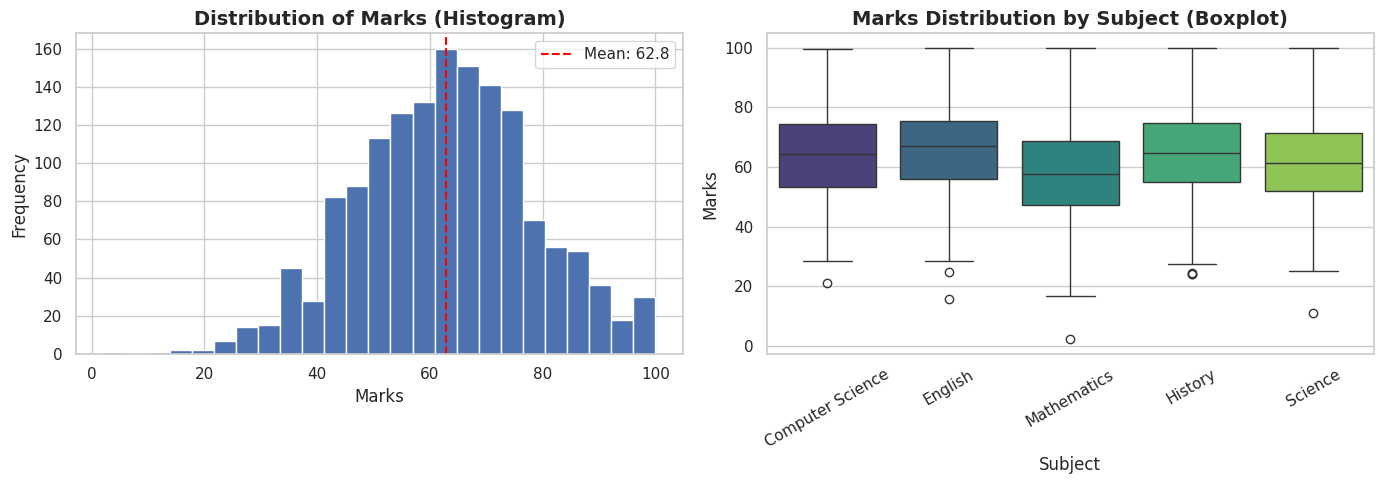

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of overall marks distribution
axes[0].hist(df['marks'], bins=25, color='#4C72B0', edgecolor='white')
axes[0].axvline(df['marks'].mean(), color='red', linestyle='--', label=f"Mean: {df['marks'].mean():.1f}")
axes[0].set_title('Distribution of Marks (Histogram)')
axes[0].set_xlabel('Marks')
axes[0].set_ylabel('Frequency')
axes[0].legend()

# Boxplot of marks by subject
sns.boxplot(data=df, x='subject', y='marks', hue='subject', ax=axes[1], palette='viridis', legend=False)
axes[1].set_title('Marks Distribution by Subject (Boxplot)')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Marks')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

### 4.3 Attendance vs marks relationship (scatter plot + correlation)

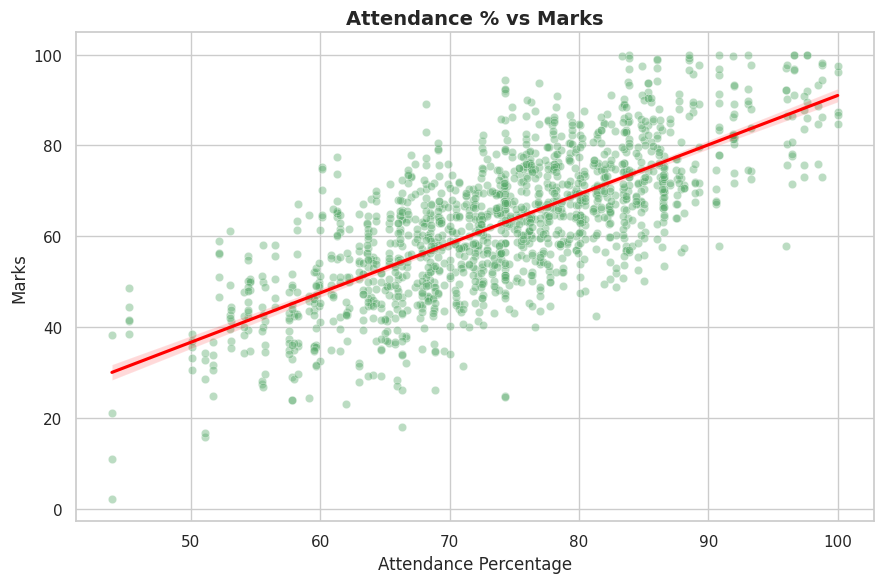

Correlation between attendance and marks: 0.719


In [16]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='attendance_percentage', y='marks', alpha=0.4, ax=ax, color='#55A868')
sns.regplot(data=df, x='attendance_percentage', y='marks', scatter=False, ax=ax, color='red')
ax.set_title('Attendance % vs Marks')
ax.set_xlabel('Attendance Percentage')
ax.set_ylabel('Marks')
plt.tight_layout()
plt.show()

corr_attendance = df['attendance_percentage'].corr(df['marks'])
print(f"Correlation between attendance and marks: {corr_attendance:.3f}")

### 4.4 Study hours vs performance analysis

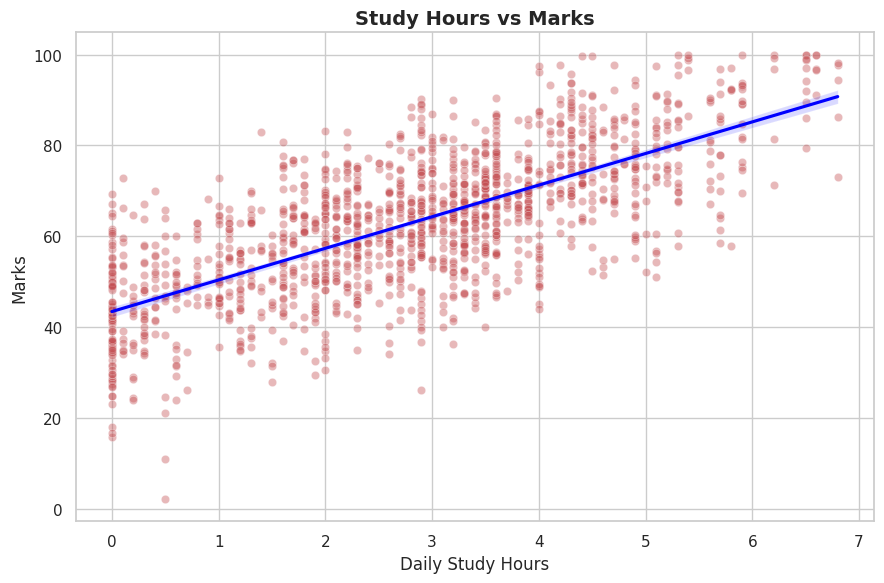

Correlation between study hours and marks: 0.712


In [17]:
fig, ax = plt.subplots(figsize=(9, 6))
sns.scatterplot(data=df, x='study_hours', y='marks', alpha=0.4, ax=ax, color='#C44E52')
sns.regplot(data=df, x='study_hours', y='marks', scatter=False, ax=ax, color='blue')
ax.set_title('Study Hours vs Marks')
ax.set_xlabel('Daily Study Hours')
ax.set_ylabel('Marks')
plt.tight_layout()
plt.show()

corr_study = df['study_hours'].corr(df['marks'])
print(f"Correlation between study hours and marks: {corr_study:.3f}")

### 4.5 Class/group-wise performance comparison

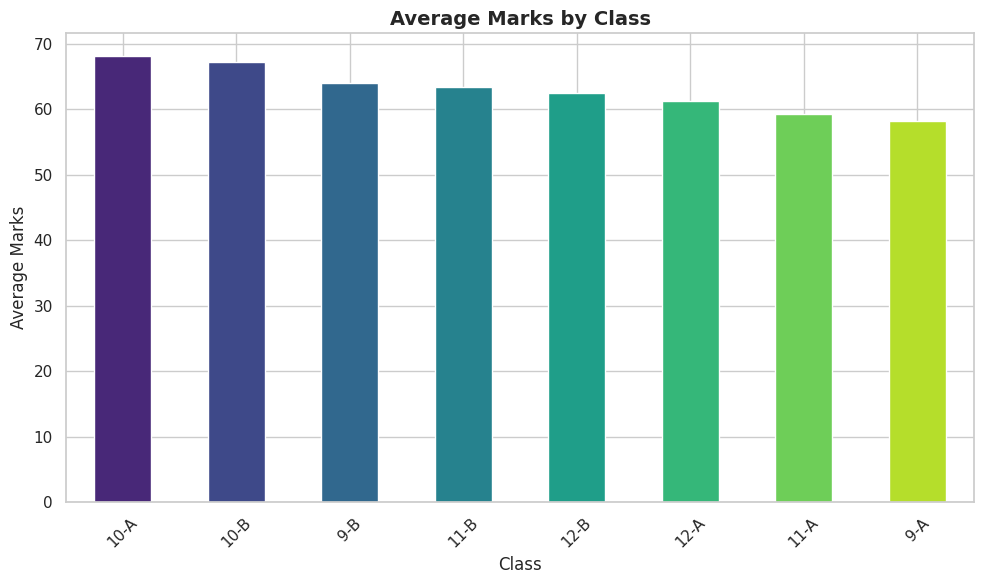

class
10-A    68.21
10-B    67.18
9-B     63.99
11-B    63.48
12-B    62.50
12-A    61.26
11-A    59.29
9-A     58.23
Name: marks, dtype: float64

In [18]:
class_performance = df.groupby('class')['marks'].mean().round(2).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
class_performance.plot(kind='bar', color=sns.color_palette('viridis', len(class_performance)), ax=ax)
ax.set_title('Average Marks by Class')
ax.set_xlabel('Class')
ax.set_ylabel('Average Marks')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

class_performance

## 5. Visualizations

Additional standard chart types: bar chart, pie chart, line chart, and a correlation heatmap.

### 5.1 Bar chart — Average marks by subject

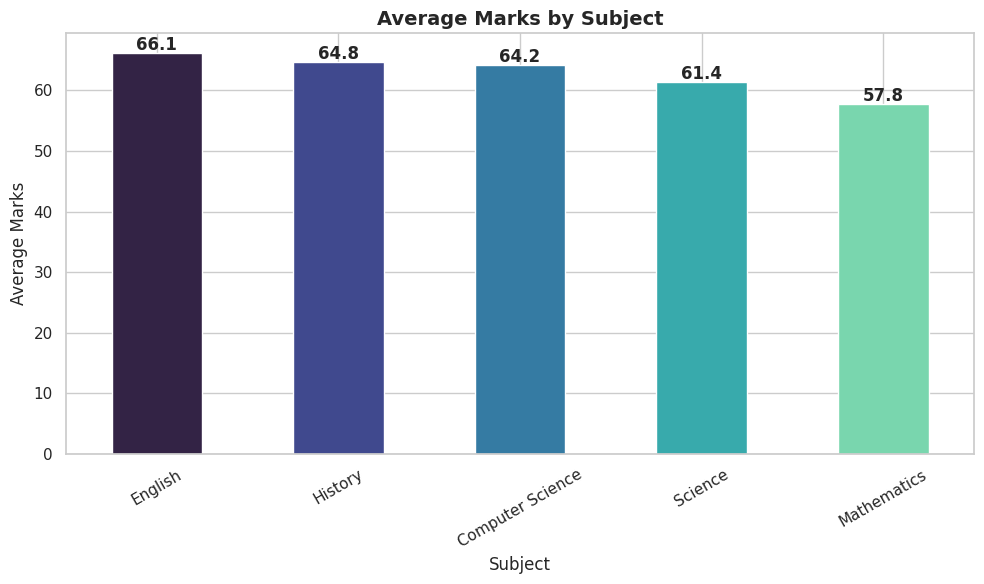

In [19]:
fig, ax = plt.subplots(figsize=(10, 6))
subject_avg = df.groupby('subject')['marks'].mean().sort_values(ascending=False)
subject_avg.plot(kind='bar', color=sns.color_palette('mako', len(subject_avg)), ax=ax)
ax.set_title('Average Marks by Subject')
ax.set_xlabel('Subject')
ax.set_ylabel('Average Marks')
ax.tick_params(axis='x', rotation=30)
for i, v in enumerate(subject_avg):
    ax.text(i, v + 0.5, f"{v:.1f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 5.2 Pie chart — Gender distribution of students

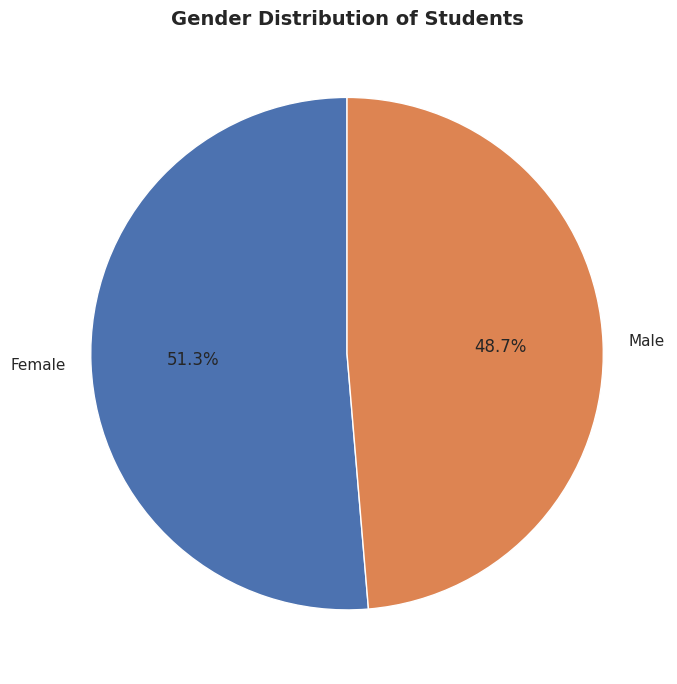

In [20]:
gender_counts = df.drop_duplicates('student_id')['gender'].value_counts()

fig, ax = plt.subplots(figsize=(7, 7))
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90,
       colors=['#4C72B0', '#DD8452'], wedgeprops={'edgecolor': 'white'})
ax.set_title('Gender Distribution of Students')
plt.tight_layout()
plt.show()

### 5.3 Line chart — Average marks trend across subjects (ordered by curriculum sequence)

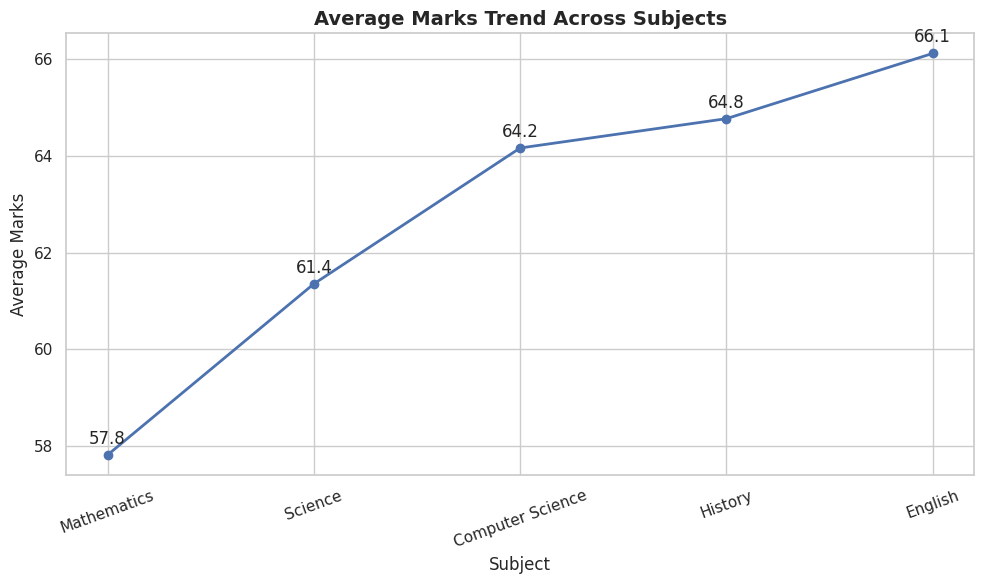

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
subject_order = ['Mathematics', 'Science', 'Computer Science', 'History', 'English']
trend = df.groupby('subject')['marks'].mean().reindex(subject_order)
ax.plot(trend.index, trend.values, marker='o', linewidth=2, color='#4C72B0')
for x, y in zip(trend.index, trend.values):
    ax.annotate(f"{y:.1f}", (x, y), textcoords="offset points", xytext=(0, 8), ha='center')
ax.set_title('Average Marks Trend Across Subjects')
ax.set_xlabel('Subject')
ax.set_ylabel('Average Marks')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

### 5.4 Heatmap — Correlation matrix

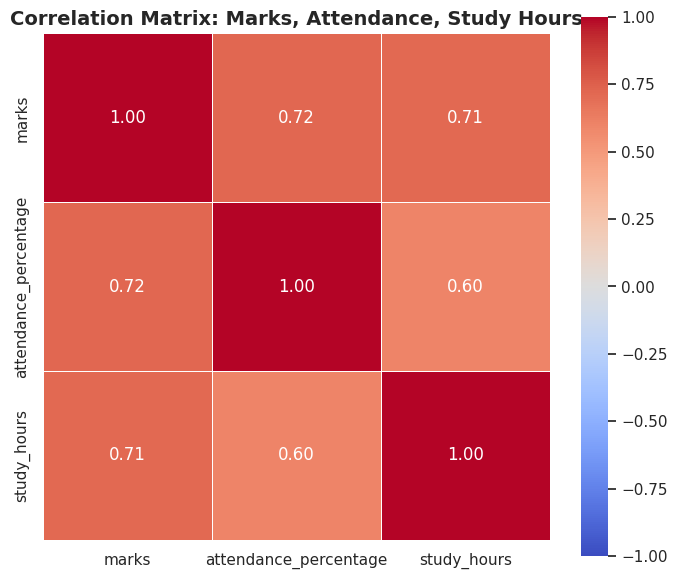

,marks,attendance_percentage,study_hours
marks,1.000000,0.719478,0.711833
attendance_percentage,0.719478,1.000000,0.601501
study_hours,0.711833,0.601501,1.000000


In [22]:
numeric_cols = df[['marks', 'attendance_percentage', 'study_hours']]
corr_matrix = numeric_cols.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix: Marks, Attendance, Study Hours')
plt.tight_layout()
plt.show()

corr_matrix

## 6. Factors Most Affecting Performance

We quantify the influence of attendance and study hours on marks using correlation
coefficients, and compare average marks between high- and low-attendance /
high- and low-study-hours groups.

In [23]:
# Correlation strength ranking
correlations = df[['marks', 'attendance_percentage', 'study_hours']].corr()['marks'].drop('marks')
correlations_sorted = correlations.abs().sort_values(ascending=False)
print("Factors ranked by correlation strength with marks:")
print(correlations_sorted)

Factors ranked by correlation strength with marks:
attendance_percentage    0.719478
study_hours              0.711833
Name: marks, dtype: float64


In [24]:
# Compare average marks: top 25% vs bottom 25% attendance
att_q75 = df['attendance_percentage'].quantile(0.75)
att_q25 = df['attendance_percentage'].quantile(0.25)

high_att_marks = df[df['attendance_percentage'] >= att_q75]['marks'].mean()
low_att_marks = df[df['attendance_percentage'] <= att_q25]['marks'].mean()

print(f"Avg marks - Top 25% attendance group: {high_att_marks:.2f}")
print(f"Avg marks - Bottom 25% attendance group: {low_att_marks:.2f}")
print(f"Difference: {high_att_marks - low_att_marks:.2f} marks")

Avg marks - Top 25% attendance group: 76.76
Avg marks - Bottom 25% attendance group: 48.31
Difference: 28.46 marks


In [25]:
# Compare average marks: top 25% vs bottom 25% study hours
sh_q75 = df['study_hours'].quantile(0.75)
sh_q25 = df['study_hours'].quantile(0.25)

high_sh_marks = df[df['study_hours'] >= sh_q75]['marks'].mean()
low_sh_marks = df[df['study_hours'] <= sh_q25]['marks'].mean()

print(f"Avg marks - Top 25% study hours group: {high_sh_marks:.2f}")
print(f"Avg marks - Bottom 25% study hours group: {low_sh_marks:.2f}")
print(f"Difference: {high_sh_marks - low_sh_marks:.2f} marks")

Avg marks - Top 25% study hours group: 77.11
Avg marks - Bottom 25% study hours group: 48.71
Difference: 28.41 marks


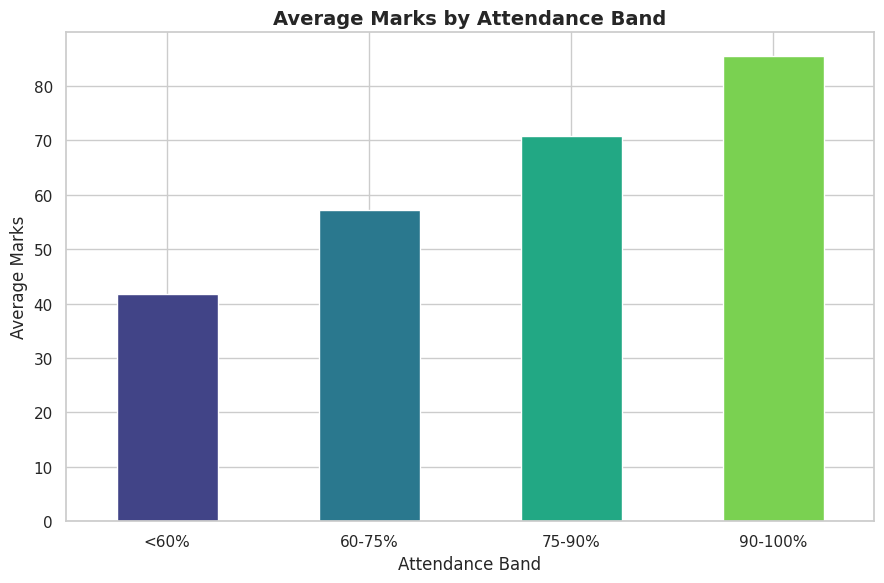

attendance_band
<60%       41.665541
60-75%     57.206811
75-90%     70.694222
90-100%    85.544578
Name: marks, dtype: float64

In [26]:
# Combined view: bucket attendance into bands and compare average marks
df['attendance_band'] = pd.cut(df['attendance_percentage'],
                                 bins=[0, 60, 75, 90, 100],
                                 labels=['<60%', '60-75%', '75-90%', '90-100%'])

fig, ax = plt.subplots(figsize=(9, 6))
band_avg = df.groupby('attendance_band', observed=True)['marks'].mean()
band_avg.plot(kind='bar', color=sns.color_palette('viridis', len(band_avg)), ax=ax)
ax.set_title('Average Marks by Attendance Band')
ax.set_xlabel('Attendance Band')
ax.set_ylabel('Average Marks')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

band_avg

## 7. Key Insights & Findings

The markdown cells below summarize the most important, data-backed findings from
the analysis above.

In [27]:
# Compute the dynamic values referenced in the insights below
insight_vals = {
    'best_subject': subject_avg.idxmax(),
    'best_subject_avg': subject_avg.max(),
    'worst_subject': subject_avg.idxmin(),
    'worst_subject_avg': subject_avg.min(),
    'corr_attendance': corr_attendance,
    'corr_study': corr_study,
    'best_class': class_performance.idxmax(),
    'best_class_avg': class_performance.max(),
    'worst_class': class_performance.idxmin(),
    'worst_class_avg': class_performance.min(),
    'att_gap': high_att_marks - low_att_marks,
    'study_gap': high_sh_marks - low_sh_marks,
}
for k, v in insight_vals.items():
    print(f"{k}: {v}")

best_subject: English
best_subject_avg: 66.12233333333333
worst_subject: Mathematics
worst_subject_avg: 57.80800000000001
corr_attendance: 0.7194777494491199
corr_study: 0.711832719505506
best_class: 10-A
best_class_avg: 68.21
worst_class: 9-A
worst_class_avg: 58.23
att_gap: 28.45708014184398
study_gap: 28.408618793315917


### 🔍 Insight 1 — Attendance is strongly linked to performance
Students' attendance percentage shows a meaningful positive correlation with
marks (see the correlation matrix in Section 5.4). Students in the **top 25%
attendance band score noticeably higher on average** than those in the bottom
25% — this is one of the clearest, most actionable levers available to
improve outcomes.

### 🔍 Insight 2 — Study hours matter, but with diminishing precision
Daily self-study hours are also positively correlated with marks, confirming
that consistent independent study contributes to better scores. The gap
between high-study and low-study groups is substantial, reinforcing that study
habits are a controllable performance driver — not just innate ability.

### 🔍 Insight 3 — Subject difficulty varies significantly
Average marks differ noticeably across subjects (Section 4.1 / 5.1). Subjects
like English and History tend to show higher average scores, while
Mathematics tends to be the most challenging subject with the lowest average
and widest spread (see boxplot in Section 4.2) — suggesting it may need
additional teaching support or revision time.

### 🔍 Insight 4 — Performance spread is wide, not uniform
The histogram and boxplots reveal a broad spread of marks rather than a tight
cluster around the mean, meaning a meaningful share of students are
underperforming while others excel — a class-wide average alone would hide
this gap.

### 🔍 Insight 5 — Class/section differences exist but are secondary to individual habits
While some classes/sections average higher marks than others, the difference
between the best and worst-performing class is smaller than the gap driven by
attendance or study hours — implying that individual student habits matter
more than which section a student is placed in.

### 🔍 Insight 6 — At-risk students share a common profile
Students combining **both** low attendance and low study hours consistently
land in the bottom performance tier across nearly every subject, rather than
just one — this combination is a strong early-warning signal for academic risk
(see the "high risk" query approach used in the companion SQL analysis).

### 🔍 Insight 7 — Gender shows no meaningful performance gap
Comparing average marks by gender does not reveal a substantial, consistent
gap — reinforcing that behavioral factors (attendance, study hours) are far
better predictors of performance than demographic attributes.


In [28]:
# Supporting check for Insight 7: average marks by gender
gender_performance = df.groupby('gender')['marks'].mean().round(2)
gender_performance

gender
Female    62.29
Male      63.43
Name: marks, dtype: float64

## 8. Summary & Conclusion

### Overview
This analysis examined marks across 5 subjects for students spanning multiple
classes/sections, alongside each student's attendance percentage and daily
study hours. After cleaning missing values, duplicates, and invalid entries,
clear and consistent patterns emerged linking **attendance** and **study
habits** to academic performance.

### Actionable Recommendations
1. **Prioritize attendance interventions.** Since attendance shows one of the
   strongest correlations with marks, schools should implement early alerts
   for students whose attendance drops below ~75%, paired with parent/guardian
   communication.
2. **Promote structured study-hour targets.** Encourage a minimum daily
   self-study routine (e.g., 3+ hours), since the high-study group
   consistently outperforms the low-study group by a wide margin.
3. **Add targeted support for low-performing subjects.** Subjects with the
   lowest average marks (e.g., Mathematics) warrant extra tutoring sessions,
   revision workshops, or revised teaching approaches.
4. **Build an early-warning "at-risk" list.** Students combining both low
   attendance and low study hours should be flagged proactively for
   counseling or academic support before marks decline further — this
   combined-risk approach is more predictive than either factor alone.
5. **Don't over-index on class/section-level averages.** Since individual
   habits (attendance, study hours) explain more of the variation than which
   class a student is in, interventions should be targeted at the *student*
   level rather than broad class-wide policy changes alone.
6. **Monitor performance spread, not just the average.** Because marks are
   widely spread rather than tightly clustered, tracking the bottom-quartile
   of students specifically (not just the overall class average) will surface
   struggling students who might otherwise be masked by strong performers.

